In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../music-sources-unified'))
if module_path not in sys.path: sys.path.append(module_path)
import unify_lib as uni

import time
import pandas as pd
from fuzzywuzzy import process, fuzz


In [2]:
%%time

DATE = time.strftime('%m-%d-%Y')
MB_LIB = '../../music-sources-unified/db_assets/musicbee_library.tsv'
MB_INBOX = '../../music-sources-unified/db_assets/musicbee_inbox.tsv'
YT_TRACK_DB = '../playlists/_tracks_db.tsv'

mb_tracks = uni.ingest_musicbee_db_assets(MB_LIB, MB_INBOX, save_tsv=False)
yt_tracks = uni.ingest_ytmusic_db_assets(YT_TRACK_DB, save_tsv=False)

# add title - artist fuzzy id (no album)
yt_tracks['fuzzy_track_id'] = yt_tracks.apply(uni.make_ytmusic_fuzzy_track_id, axis=1)
mb_tracks['fuzzy_track_id'] = mb_tracks.apply(uni.make_musicbee_fuzzy_track_id, axis=1)

print(f"musicbee rating breakdown\n{mb_tracks['Rating'].value_counts()}")
print(f"ytmusic like breakdown\n{yt_tracks['likeStatus'].value_counts()}")
yt_tracks_like = yt_tracks.loc[yt_tracks['likeStatus'] == 'LIKE']

Loaded 98884 musicbee tracks
mb_tracks columns: Index(['Artist', 'Album Artist', 'Album', 'Genre', 'Play Count', 'Rating',
       'Title', 'Track Count', 'Track #', 'Year', 'Path', 'fuzzy_id',
       'fuzzy_album_id'],
      dtype='object')

Loaded 156676 ytmusic tracks
yt_tracks columns: Index(['title', 'album', 'likeStatus', 'duration', 'artistId', 'artist',
       'albumId', 'playlists', 'keywords', 'averageRating', 'viewCount',
       'release', 'isAvailable', 'isExplicit', 'albumArtist',
       'albumTrackCount', 'albumDuration', 'albumYear', 'albumType',
       'duration_seconds', 'videoType', 'fuzzy_id', 'fuzzy_album_id'],
      dtype='object')

musicbee rating breakdown
Rating
 4.0    16875
 3.0    10468
 2.0     7703
 3.5     3479
 5.0      720
 2.5      299
 1.0      263
 3.8      114
 4.5       26
 1.5       13
 0.5        3
-1.0        1
Name: count, dtype: int64
ytmusic like breakdown
likeStatus
INDIFFERENT    109360
LIKE            45338
DISLIKE           976
Name: count,

In [3]:
# Params

# Save tsv with query, match and score
match_tsv_name = '../../music-sources-unified/tsvs/ytmusic_like_mb_matches.tsv'
# For backup, stores incomplete task output
match_tsv_name_tmp = '../../music-sources-unified/logs/tmp_ytmusic_like_mb_matches.tsv'
# Save m3u for passing matches
m3u_file = '../../music-sources-unified/m3u/ytmusic_like_mb_matches.m3u'

# Score > score_thresh is considered a match, set by manually browsing ~90s scores
score_thresh = 92
# Speed up by skipping tracks already matched (score > score_thresh)
skip_already_matched = True


def get_top_match(query, pool, scorer=fuzz.token_set_ratio):
    match, score = process.extract(query, pool, limit=1, scorer=scorer)[0]
    return {'query': query, 'match': match, 'score': score}

def get_eta(n_complete, n_total, start_time, verbose=True):
    fps = n_complete  / (time.time() - start_time) 
    eta_hr = (n_total - n_complete)/fps / 60. / 60.
    if verbose:
        print(f"\nProcessed {n_complete} of {n_total} @ {fps:0.2f}fps, eta: {eta_hr:0.1f} hours")   
    return eta_hr


In [4]:
%%time

log_freq = 500
mb_pool = mb_tracks['fuzzy_track_id'].unique()
yt_queries = yt_tracks_like['fuzzy_track_id'].unique()

# Remove already matched ty entries from yt_queries pool
if skip_already_matched:
  last_mb_match = pd.read_csv(match_tsv_name, sep='\t', index_col=0)
  last_mb_match_pass = last_mb_match.loc[last_mb_match['score'] > score_thresh]
  print(f'Loaded {len(last_mb_match)} results from last run, {len(last_mb_match_pass)} are passing above score threshold: {score_thresh}')
  yt_query_len = len(yt_queries)
  yt_queries = sorted(list(frozenset(yt_tracks_like['fuzzy_track_id']) - frozenset(last_mb_match_pass['query'])))
  print(f'Reduced yt like query queue from {yt_query_len} to {len(yt_queries)} after removing already matched entries')
  
# Get MB Track Match for YT Like Entry
# takes 11hrs! from scratch (last_mb_match)
print(f"Attempting {len(yt_queries)} ytmusic track queries to musicbee pool with size {len(mb_pool)}")
mb_match = []
t0 = time.time()
for i, yt_fuzzy_track_id in enumerate(yt_queries):
    mb_match.append(get_top_match(yt_fuzzy_track_id, mb_pool, scorer=fuzz.token_set_ratio))
    if i % log_freq == 0:
        print(f'{100*i/len(yt_queries):0.2f}%', end='...')
    if (i+1) % (log_freq*10) == 0:
        get_eta(i+1, len(yt_queries), t0)
        pd.DataFrame(mb_match).to_csv(match_tsv_name_tmp, sep='\t')

match_tsv_name_tmp
# Save tsv with query, match and score 
mb_match = pd.concat([last_mb_match_pass, pd.DataFrame(mb_match)]).reset_index(drop=True)
mb_match.to_csv(match_tsv_name, sep='\t')
print(f"\nScore stats:\n{mb_match['score'].describe()}")

# Save m3u with matches
mb_match_pass = mb_match.loc[mb_match['score'] > score_thresh]
print(f'{100*len(mb_match_pass)/len(mb_match):0.1f}% of {len(mb_match)} matches are above the score threshold {score_thresh}')
mb_like_ids = set()
for match in mb_match_pass['match'].unique():
  mb_like_ids |= frozenset(mb_tracks.loc[mb_tracks['fuzzy_track_id']  == match]['Path'])
mb_like_ids = pd.Series(sorted(list(mb_like_ids))).dropna()
mb_like_ids.to_csv( m3u_file, sep='\t', header=False, index=False)
print(f'{len(mb_like_ids)} musicbee liked track paths')
# after loading m3u into musicbee...
# 17376 in musicbee playlist, 1827 could be liked, 15449 already liked in music bee


Loaded 33097 results from last run, 21935 are passing above score threshold: 92
Reduced yt like query queue from 33393 to 11458 after removing already matched entries
Attempting 11458 ytmusic track queries to musicbee pool with size 95952
0.00%...4.36%...8.73%...13.09%...17.46%...21.82%...26.18%...30.55%...34.91%...39.27%...
Processed 5000 of 11458 @ 0.59fps, eta: 3.0 hours
43.64%...48.00%...52.37%...56.73%...61.09%...65.46%...69.82%...74.18%...78.55%...82.91%...
Processed 10000 of 11458 @ 0.60fps, eta: 0.7 hours
87.28%...91.64%...96.00%...
Score stats:
count    33393.000000
mean        91.787021
std         12.410694
min         17.000000
25%         82.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: score, dtype: float64
66.0% of 33393 matches are above the score threshold 92
18299 musicbee liked track paths
CPU times: total: 5h 15min 56s
Wall time: 5h 18min 4s


<AxesSubplot: title={'center': 'Non Perfect Scores'}, ylabel='Frequency'>

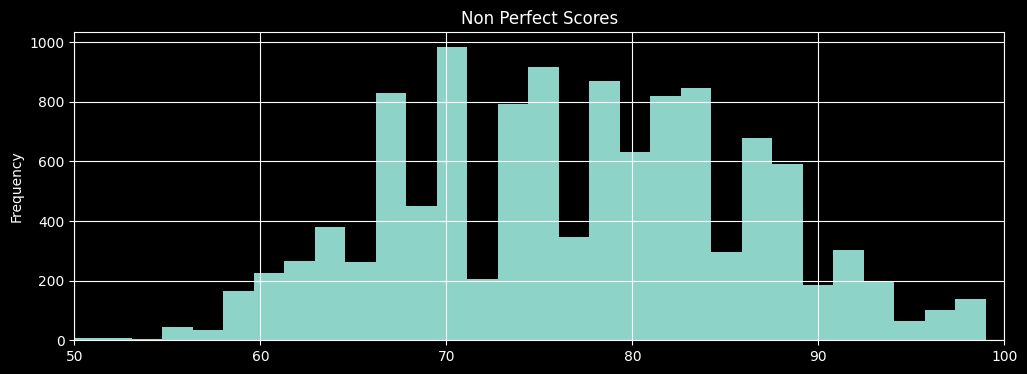

In [12]:
# LAST RUN
# Loaded 32266 results from last run, 21707 are passing above score threshold: 92
# Reduced yt like query queue from 33097 to 11390 after removing already matched entries
# Attempting 11390 ytmusic track queries to musicbee pool with size 95825
# 0.00%...4.39%...8.78%...13.17%...17.56%...21.95%...26.34%...30.73%...35.12%...39.51%...
# Processed 5000 of 11390 @ 0.57fps, eta: 3.1 hours
# 43.90%...48.29%...52.68%...57.07%...61.46%...65.85%...70.24%...74.63%...79.02%...83.41%...
# Processed 10000 of 11390 @ 0.59fps, eta: 0.7 hours
# 87.80%...92.19%...96.58%...
# Score stats:
# count    33097.000000
# mean        91.844880
# std         12.385165
# min         17.000000
# 25%         83.000000
# 50%        100.000000
# 75%        100.000000
# max        100.000000
# Name: score, dtype: float64
# 66.3% of 33097 matches are above the score threshold 92
# 18209 musicbee liked track paths
# CPU times: total: 5h 15min 26s
# Wall time: 5h 19min 37s
# mb_match.loc[mb_match['score'] < 99.9, 'score'].plot.hist(bins=50, title='Non Perfect Scores', figsize=(12, 4), grid=True, xlim=(50, 100))